In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib
import os
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_csv('housing.csv')

In [8]:
df = df[['price','region','property_type','year_built',
         'beds','baths','sqft','parking_total_spaces','interior_features',
         'walk_score','bike_score','fire_risk','wind_risk','air_risk','heat_risk']]

df["region"] = df["region"].astype(str).str.strip()
df["property_type"] = df["property_type"].astype(str).str.strip()
df["interior_features"] = df["interior_features"].fillna("").astype(str).str.strip()
df["region"] = df["region"].replace("", pd.NA)
df["property_type"] = df["property_type"].replace("", pd.NA)


df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8983 entries, 0 to 8982
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   price                 8983 non-null   str    
 1   region                8983 non-null   str    
 2   property_type         8983 non-null   str    
 3   year_built            8667 non-null   float64
 4   beds                  8594 non-null   float64
 5   baths                 8893 non-null   float64
 6   sqft                  8589 non-null   str    
 7   parking_total_spaces  7537 non-null   float64
 8   interior_features     8983 non-null   str    
 9   walk_score            8595 non-null   str    
 10  bike_score            8372 non-null   str    
 11  fire_risk             7874 non-null   str    
 12  wind_risk             7868 non-null   str    
 13  air_risk              7874 non-null   str    
 14  heat_risk             7874 non-null   str    
dtypes: float64(4), str(11)
memory us

In [9]:
df.head()

,price,region,property_type,year_built,beds,baths,sqft,parking_total_spaces,interior_features,walk_score,bike_score,fire_risk,wind_risk,air_risk,heat_risk
0,"$999,000",Arlington,single family,1880.0,3.0,2.0,"1,415",4.0,fireplace; stainless steel; marble,81/100,61/100,Minimal (1/10),Major (6/10),Moderate (3/10),Major (5/10)
1,"$799,000",Arlington,single family,1880.0,2.0,1.0,"1,064",3.0,granite countertops; stainless steel; fireplace,69/100,59/100,Minimal (1/10),Major (6/10),Moderate (3/10),Major (5/10)
2,"$899,000",Arlington,single family,1952.0,2.0,1.0,"1,628",5.0,fireplace; laminate,32/100,35/100,Minimal (1/10),Major (6/10),Moderate (3/10),Major (5/10)
3,"$998,000",Arlington,single family,1926.0,3.0,2.0,"1,824",2.0,fireplace; hardwood floors,84/100,54/100,Minimal (1/10),Major (6/10),Moderate (3/10),Major (6/10)
4,"$668,000",Arlington,condo,1908.0,2.0,2.0,"1,221",1.0,fireplace; hardwood floor,77/100,96/100,Minimal (1/10),Major (6/10),Moderate (3/10),Major (6/10)


In [10]:
df['year_built'] = 2026 - df['year_built']

df["price"] = (
    df["price"]
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .pipe(pd.to_numeric, errors="coerce")
)

df["sqft"] = (
    df["sqft"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .pipe(pd.to_numeric, errors="coerce")
)

df["interior_features"] = (
    df["interior_features"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

df["interior_skylight"] = df["interior_features"].str.contains("skylight", regex=False).astype(int)
df["interior_crown_molding"] = df["interior_features"].str.contains("crown molding", regex=False).astype(int)
df["interior_granite_countertops"] = df["interior_features"].str.contains("granite countertops", regex=False).astype(int)
df = df.drop(columns=["interior_features"])

for col in ["walk_score", "bike_score"]:
    df[col] = (
        df[col]
        .astype(str)
        .str.extract(r"(\d+)\s*/\s*100")[0]
        .pipe(pd.to_numeric, errors="coerce")
    )
    
risk_cols = ["fire_risk", "wind_risk", "air_risk", "heat_risk"]

for col in risk_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.extract(r"(\d+)\s*/\s*10")[0]
        .pipe(pd.to_numeric, errors="coerce")
    )

num_cols = ['price','year_built','beds','baths','sqft',
            'parking_total_spaces','walk_score','bike_score',
            'fire_risk','air_risk','heat_risk']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

top_regions = df["region"].value_counts().nlargest(10).index
df["region_grouped"] = df["region"].where(
    df["region"].isin(top_regions),
    "Other"
)


df["property_type"] = (
    df["property_type"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace("-", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
)

df["property_type"] = df["property_type"].replace({
    "single family": "single family",
    "townhouse": "townhouse",
    "condo": "condo",
    "multi family": "multi family"
})

df = pd.get_dummies(
    df,
    columns=["property_type", "region_grouped"],
    drop_first=True
)

df = df.drop(columns=["region"])


print(df[[
    "interior_skylight",
    "interior_crown_molding",
    "interior_granite_countertops"
]].sum())

interior_skylight               426
interior_crown_molding          223
interior_granite_countertops    445
dtype: int64


<Axes: >

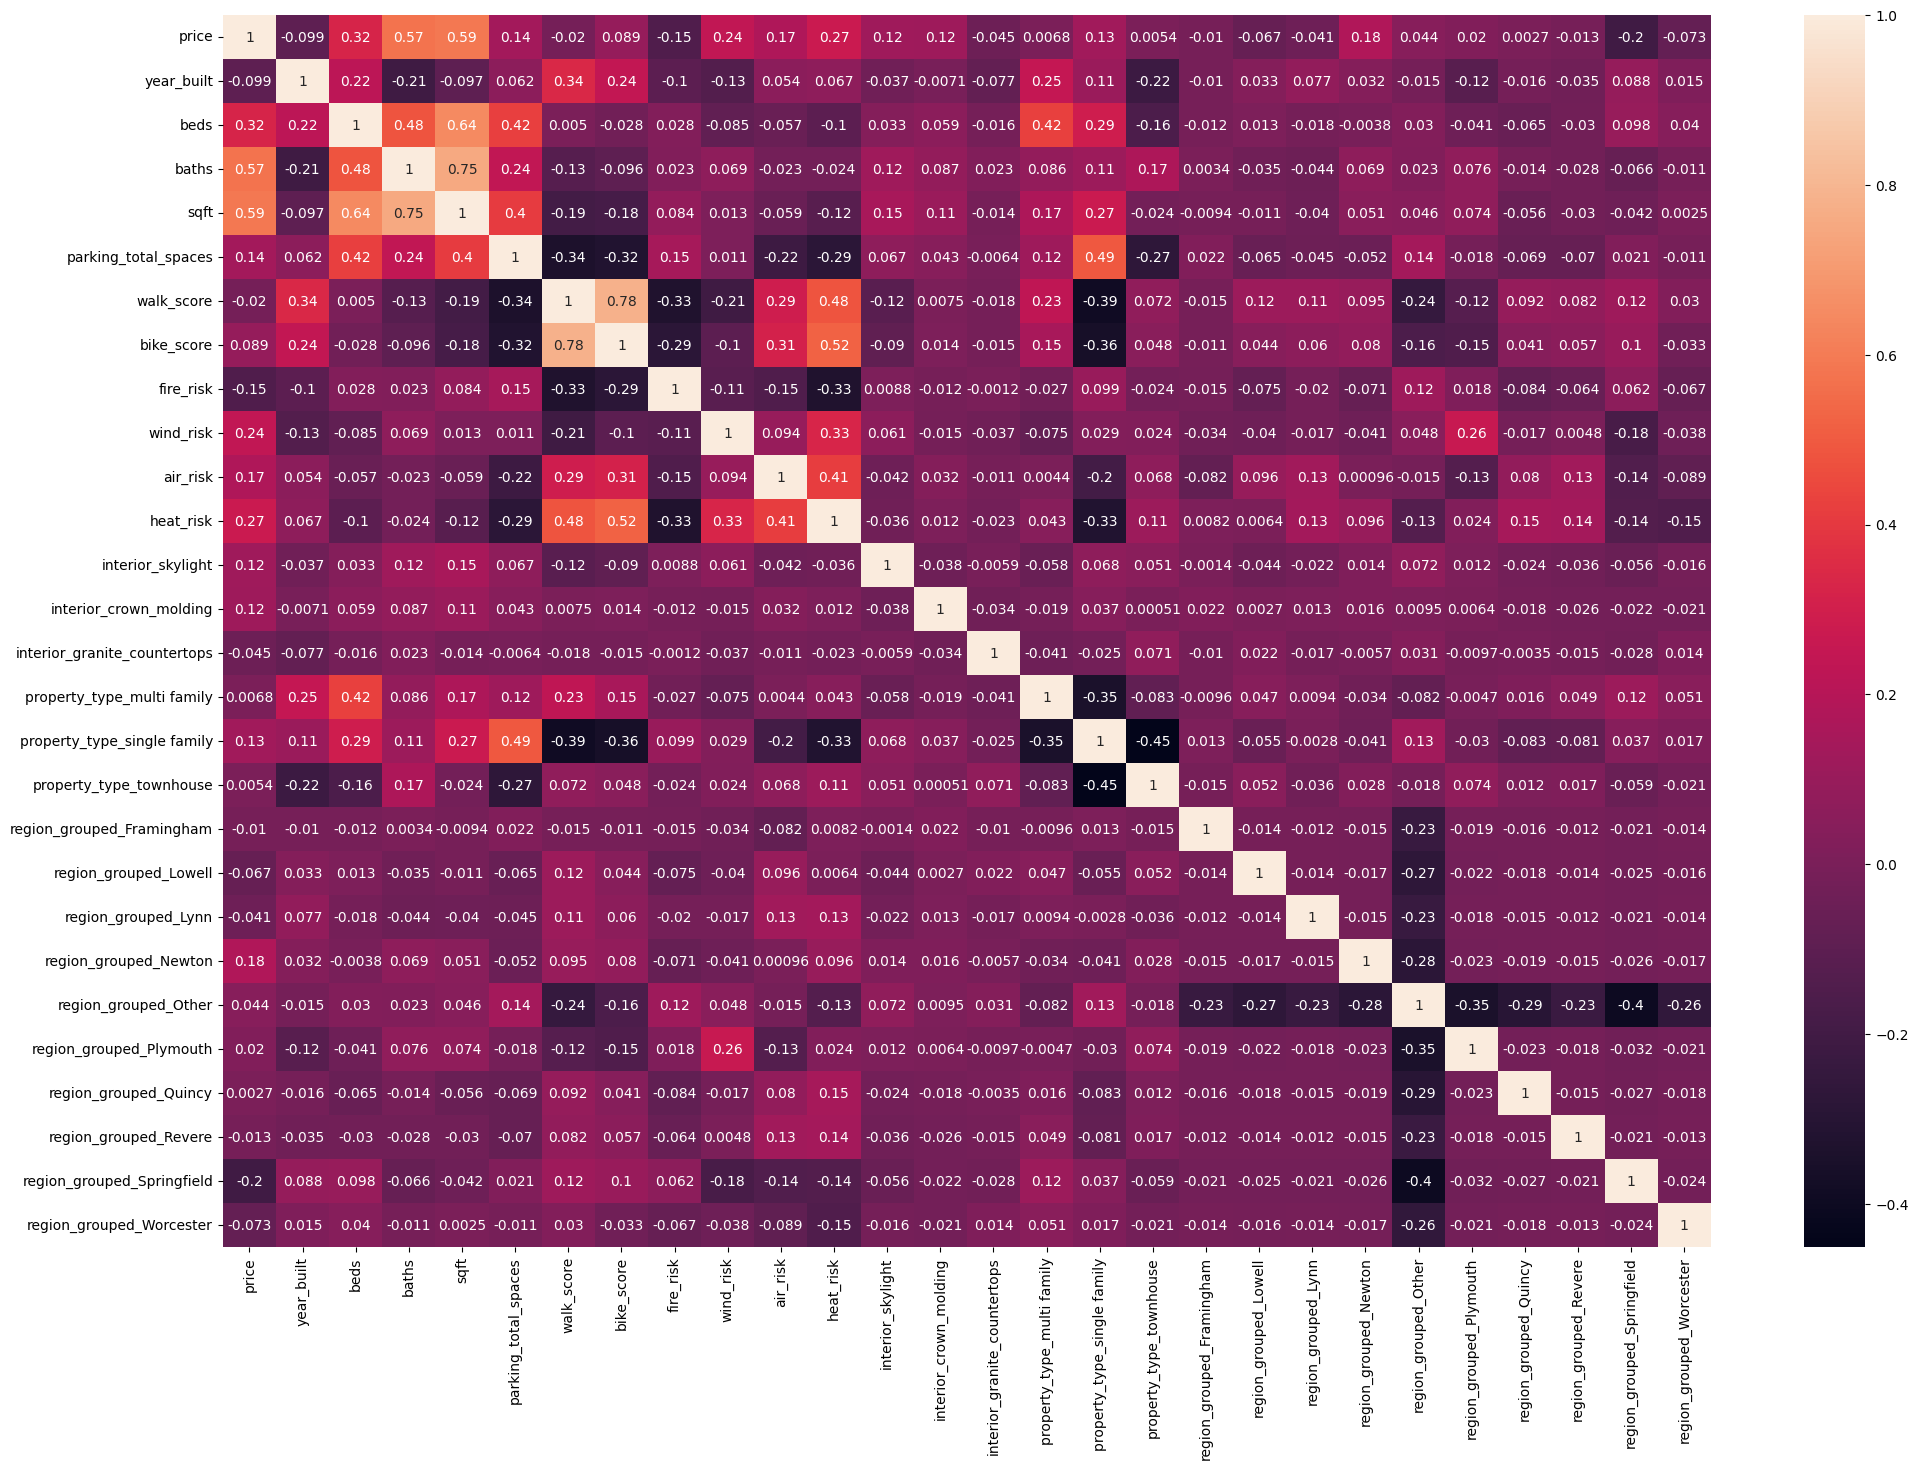

In [11]:
plt.figure(figsize=(24, 16))
sns.heatmap(df.corr(), annot=True)

In [12]:
def plotCorrelationMatrix(df, graphWidth):
    #df = df.dropna('columns') # drop columns with NaN
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    if df.shape[1] < 2:
        print(f'No correlation plots shown: The number of non-NaN or constant columns ({df.shape[1]}) is less than 2')
        return
    corr = df.corr()
    plt.figure(num=None, figsize=(graphWidth, graphWidth), dpi=80, facecolor='w', edgecolor='k')
    corrMat = plt.matshow(corr, fignum = 1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.title(f'Correlation Matrix for housing', fontsize=15)
    plt.show()

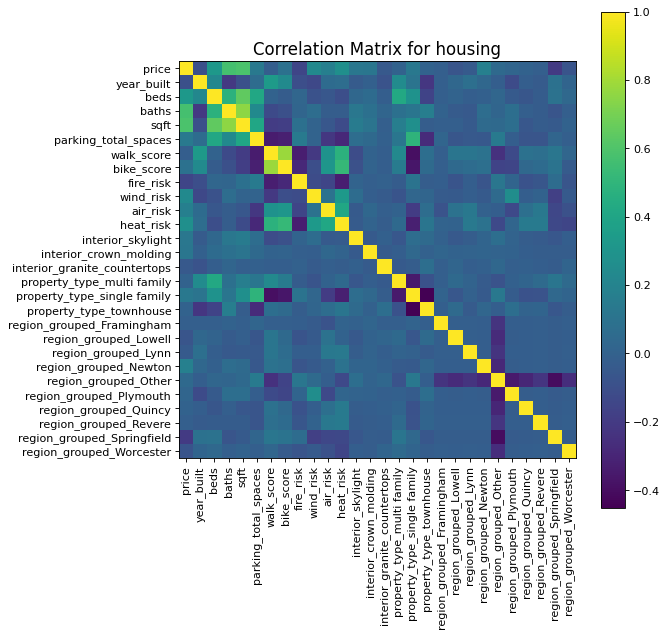

In [13]:
plotCorrelationMatrix(df, 8)

In [14]:
df_model = df[['price','year_built','beds','baths','sqft','parking_total_spaces','fire_risk',
              'wind_risk','air_risk','heat_risk','interior_skylight','interior_crown_molding','property_type_single family',
               'region_grouped_Newton','region_grouped_Springfield']]

df_model['sqft'] = df_model['sqft'] / 1000
y = np.log1p(df_model['price']) 
X = df_model.drop(columns = ['price'])
df_model.info()

<class 'pandas.DataFrame'>
Index: 4183 entries, 0 to 8982
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   price                        4183 non-null   int64  
 1   year_built                   4183 non-null   float64
 2   beds                         4183 non-null   float64
 3   baths                        4183 non-null   float64
 4   sqft                         4183 non-null   float64
 5   parking_total_spaces         4183 non-null   float64
 6   fire_risk                    4183 non-null   float64
 7   wind_risk                    4183 non-null   float64
 8   air_risk                     4183 non-null   float64
 9   heat_risk                    4183 non-null   float64
 10  interior_skylight            4183 non-null   int64  
 11  interior_crown_molding       4183 non-null   int64  
 12  property_type_single family  4183 non-null   bool   
 13  region_grouped_Newton        4183 

<Axes: >

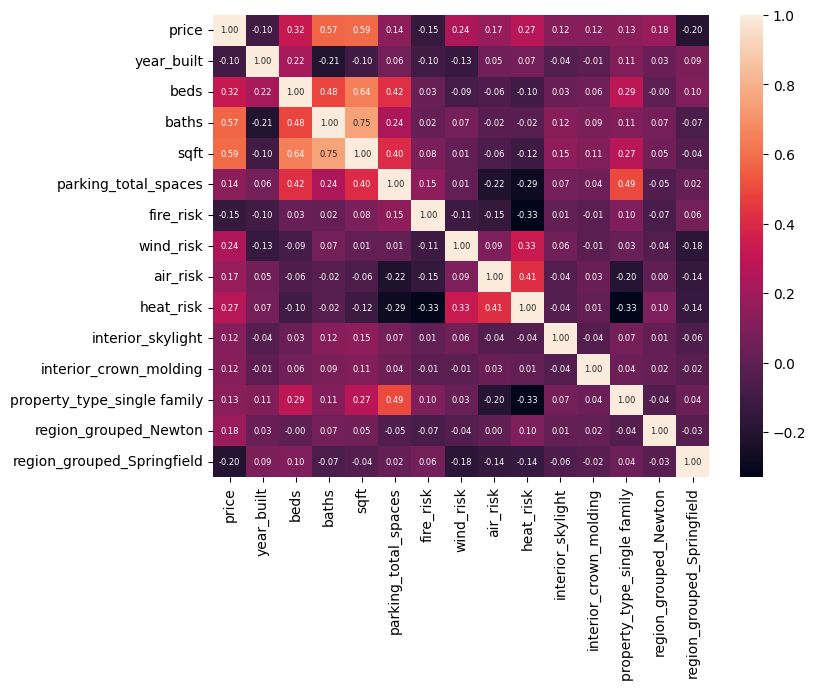

In [30]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_model.corr(), annot=True, fmt=".2f", annot_kws={"size": 6})

In [16]:
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)
X = X.select_dtypes(include=[np.number])
vif_df = pd.DataFrame()
vif_df["feature"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_df.sort_values("VIF", ascending=False))

                        feature        VIF
8                     heat_risk  43.137489
6                     wind_risk  35.579919
7                      air_risk  24.739340
3                          sqft  21.487047
1                          beds  19.954833
2                         baths  18.695172
4          parking_total_spaces   7.302437
0                    year_built   4.511615
5                     fire_risk   4.441886
11  property_type_single family   4.156716
9             interior_skylight   1.160471
13   region_grouped_Springfield   1.092050
10       interior_crown_molding   1.076048
12        region_grouped_Newton   1.052490


In [17]:
X = df_model.drop(columns = ['price','heat_risk','wind_risk'])

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3346, 12)
X_test shape: (837, 12)
y_train shape: (3346,)
y_test shape: (837,)


In [19]:
def lm(X_train,y_train,X_test,y_test):
    model = LinearRegression()
    model.fit(X_train, y_train)
    model_pred = model.predict(X_test)
    
    model_mae = mean_absolute_error(y_test, model_pred)
    model_rmse = np.sqrt(mean_squared_error(y_test, model_pred))
    model_r2 = r2_score(y_test, model_pred)

    model_results = pd.DataFrame({
        "model": ["Linear Regression"],
        "MAE": [round(model_mae, 4)],
        "RMSE": [round(model_rmse, 4)],
        "R2": [round(model_r2, 4)]
    })
    
    return model_results

In [20]:
def ridge(X_train,y_train,X_test,y_test):
    model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=0.1))
    ])
    model.fit(X_train, y_train)
    model_pred = model.predict(X_test)
    
    model_mae = mean_absolute_error(y_test, model_pred)
    model_rmse = np.sqrt(mean_squared_error(y_test, model_pred))
    model_r2 = r2_score(y_test, model_pred)

    model_results = pd.DataFrame({
        "model": ["Ridge Regression"],
        "MAE": [round(model_mae, 4)],
        "RMSE": [round(model_rmse, 4)],
        "R2": [round(model_r2, 4)]
    })
    
    return model_results

In [21]:
def lasso(X_train,y_train,X_test,y_test):
    model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.1))
    ])
    model.fit(X_train, y_train)
    model_pred = model.predict(X_test)
    
    model_mae = mean_absolute_error(y_test, model_pred)
    model_rmse = np.sqrt(mean_squared_error(y_test, model_pred))
    model_r2 = r2_score(y_test, model_pred)

    model_results = pd.DataFrame({
        "model": ["LASSO Regression"],
        "MAE": [round(model_mae, 4)],
        "RMSE": [round(model_rmse, 4)],
        "R2": [round(model_r2, 4)]
    })
    
    return model_results

In [22]:
def rf(X_train,y_train,X_test,y_test):
    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    model_pred = model.predict(X_test)
    
    model_mae = mean_absolute_error(y_test, model_pred)
    model_rmse = np.sqrt(mean_squared_error(y_test, model_pred))
    model_r2 = r2_score(y_test, model_pred)

    model_results = pd.DataFrame({
        "model": ["Random Forest Regression"],
        "MAE": [round(model_mae, 4)],
        "RMSE": [round(model_rmse, 4)],
        "R2": [round(model_r2, 4)]
    })
    
    return model_results

In [23]:
def svr(X_train,y_train,X_test,y_test):
    model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(kernel="rbf", C=100, epsilon=0.1, gamma="scale"))
    ])
    model.fit(X_train, y_train)
    model_pred = model.predict(X_test)
    
    model_mae = mean_absolute_error(y_test, model_pred)
    model_rmse = np.sqrt(mean_squared_error(y_test, model_pred))
    model_r2 = r2_score(y_test, model_pred)

    model_results = pd.DataFrame({
        "model": ["Support Vector Regression"],
        "MAE": [round(model_mae, 4)],
        "RMSE": [round(model_rmse, 4)],
        "R2": [round(model_r2, 4)]
    })
    
    return model_results

In [24]:
lm_results = lm(X_train,y_train,X_test,y_test)
ridge_results = ridge(X_train,y_train,X_test,y_test)
lasso_results = lasso(X_train,y_train,X_test,y_test)
rf_results = rf(X_train,y_train,X_test,y_test)
svr_results = svr(X_train,y_train,X_test,y_test)


comparison_results = pd.concat(
    [lm_results, ridge_results, lasso_results, rf_results, svr_results],
    ignore_index=True
).sort_values("RMSE", ascending=True)

display(comparison_results)

,model,MAE,RMSE,R2
3,Random Forest Regression,0.2458,0.3259,0.6127
0,Linear Regression,0.2593,0.3442,0.5680
1,Ridge Regression,0.2593,0.3442,0.5680
4,Support Vector Regression,0.2768,0.3707,0.4989
2,LASSO Regression,0.3118,0.4022,0.4099


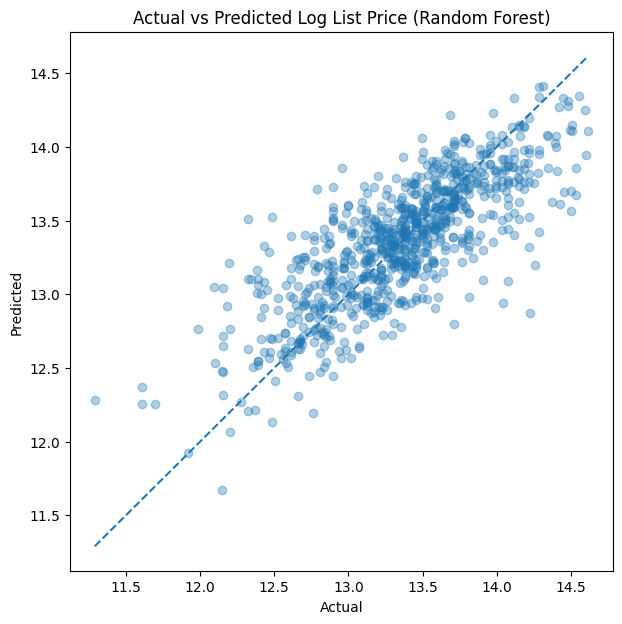

In [25]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
    )
model.fit(X_train, y_train)
rf_pred = model.predict(X_test)


plot_df = pd.DataFrame({
    "actual": y_test,
    "predicted": rf_pred
})

plt.figure(figsize=(7, 7))
plt.scatter(plot_df["actual"], plot_df["predicted"], alpha=0.35)

min_val = min(plot_df["actual"].min(), plot_df["predicted"].min())
max_val = max(plot_df["actual"].max(), plot_df["predicted"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.title("Actual vs Predicted Log List Price (Random Forest)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()